# Gradient Boosting Regressor (LightGBM) - From scratch and library approach


### 1. Cơ chế hoạt động của thuật toán Gradient Boosting & LightGBM

* **Nguyên lý Gradient Boosting:** Xây dựng mô hình cộng dồn bằng cách huấn luyện tuần tự các mô hình yếu (thường là các cây quyết định nhỏ) để giảm thiểu hàm mất mát $L(y, \hat{y})$. Ở mỗi bước, cây quyết định mới được huấn luyện để dự báo phần dư (Residuals/Gradients) của mô hình trước đó. Dự báo được cập nhật theo tỷ lệ học tập (Learning Rate) $\eta$:
  $$\hat{y}^{(m)}(x) = \hat{y}^{(m-1)}(x) + \eta \cdot h_m(x)$$

* **Histogram-based Split Finder:** Thay vì duyệt qua toàn bộ giá trị thực của các đặc trưng liên tục, dữ liệu được gom vào $K$ bins rời rạc (thường dùng 32 hoặc 255 bins). Việc tính toán Gain của các điểm chia chỉ cần thực hiện trên các bins này, giúp tăng tốc độ huấn luyện vượt trội và giảm dung lượng bộ nhớ.

* **Leaf-wise Tree Growth:** LightGBM phát triển cây theo hướng ưu tiên node có độ giảm loss lớn nhất (Best-first) thay vì phát triển đều theo từng cấp (Level-wise). Điều này giúp mô hình đạt độ sâu tối ưu nhanh hơn và giảm thiểu sai số tốt hơn khi được kiểm soát bởi tham số độ sâu tối đa (`max_depth`).

### 2. Các bước thực hiện trong mô hình tự viết (Scratch)

* **Bước 1 (Binned Features):** Chia các đặc trưng liên tục thành các khoảng rời rạc (bins) dựa trên phân vị (percentiles).
* **Bước 2 (Dự báo cơ sở):** Khởi tạo giá trị dự báo ban đầu bằng giá trị trung bình của tập nhãn $y$.
* **Bước 3 (Tính toán Gradient):** Với mỗi cây quyết định, tính phần dư (residuals) giữa giá trị thực tế và dự báo hiện tại: $g_i = y_i - \hat{y}_i$.
* **Bước 4 (Huấn luyện cây Leaf-wise):**
  * Khởi tạo node gốc chứa toàn bộ chỉ số mẫu.
  * Tìm kiếm cặp đặc trưng và ngưỡng chia (bin) tốt nhất để tối đa hóa lượng Gain.
  * Chia dữ liệu thành hai nhánh trái/phải vật lý và tiếp tục chọn node lá có gain tốt nhất để chia nhánh cho đến khi đạt `max_leaf_nodes` hoặc `max_depth`.
* **Bước 5 (Cập nhật mô hình):** Cập nhật dự báo của mô hình bằng cách cộng dồn dự báo từ cây quyết định mới nhân với Learning Rate.

## Triển khai `LightGBM` không dùng thư viện


Import thư viện cần thiết trước khi code


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
import os
import sys
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Thêm thư mục root vào sys.path để import utils
sys.path.append(os.path.abspath(os.path.join('..')))
from practice_2.utils.custom_cv import CustomKFold
from practice_2.utils.custom_hyperparameter_tuning import CustomGridSearchCV

# Đường dẫn nạp dữ liệu
DATA_DIR = './data/ready_for_train'

X_train = joblib.load(os.path.join(DATA_DIR, 'X_train_final.pkl'))
X_test = joblib.load(os.path.join(DATA_DIR, 'X_test_final.pkl'))
y_train = joblib.load(os.path.join(DATA_DIR, 'y_train_log.pkl'))
y_test = joblib.load(os.path.join(DATA_DIR, 'y_test_log.pkl'))

# Chuyển nhãn về dạng 1D numpy array
if hasattr(y_train, 'values'):
    y_train = y_train.values.flatten()
else:
    y_train = np.array(y_train).flatten()

if hasattr(y_test, 'values'):
    y_test = y_test.values.flatten()
else:
    y_test = np.array(y_test).flatten()

print('Kích thước tập Train:', X_train.shape)
print('Kích thước tập Test :', X_test.shape)

Kích thước tập Train: (79565, 14)
Kích thước tập Test : (19892, 14)


Triển khai thuật toán Leaf-wise Tree Regressor dựa trên Histogram và Gradient


In [2]:
import sys
import numpy as np

class LeafNode:
    def __init__(self, sample_indices, depth, weight, score):
        self.sample_indices = sample_indices
        self.depth = depth
        self.weight = weight
        self.score = score
        self.is_leaf = True
        
        self.feature_idx = None
        self.threshold = None
        self.left_child = None
        self.right_child = None
        self.gain = -1.0

class LeafWiseTreeRegressor:
    def __init__(self, max_depth=3, max_leaf_nodes=8, l2_reg=1.0, min_child_samples=5):
        self.max_depth = max_depth
        self.max_leaf_nodes = max_leaf_nodes
        self.l2_reg = l2_reg
        self.min_child_samples = min_child_samples
        self.root = None
        self.leaves = []

    def _find_best_split(self, X_binned, gradients, sample_indices, n_bins):
        n_samples = len(sample_indices)
        if n_samples <= 2 * self.min_child_samples:
            return None, None, -1.0
            
        G_total = np.sum(gradients[sample_indices])
        H_total = n_samples
        
        best_gain = -1.0
        best_feat = None
        best_thresh = None
        
        X_sub = X_binned[sample_indices]
        grad_sub = gradients[sample_indices]
        
        n_features = X_binned.shape[1]
        for f in range(n_features):
            max_val = int(np.max(X_sub[:, f]))
            if max_val == 0:
                continue
            
            hist_H = np.bincount(X_sub[:, f])
            hist_G = np.bincount(X_sub[:, f], weights=grad_sub)
            
            if len(hist_G) < max_val + 1:
                hist_G = np.pad(hist_G, (0, max_val + 1 - len(hist_G)))
                hist_H = np.pad(hist_H, (0, max_val + 1 - len(hist_H)))
                
            G_L = 0.0
            H_L = 0
            
            for b in range(len(hist_G) - 1):
                G_L += hist_G[b]
                H_L += hist_H[b]
                G_R = G_total - G_L
                H_R = H_total - H_L
                
                if H_L >= self.min_child_samples and H_R >= self.min_child_samples:
                    gain = 0.5 * (
                        (G_L ** 2) / (H_L + self.l2_reg) +
                        (G_R ** 2) / (H_R + self.l2_reg) -
                        (G_total ** 2) / (H_total + self.l2_reg)
                    )
                    if gain > best_gain:
                        best_gain = gain
                        best_feat = f
                        best_thresh = b
                        
        return best_feat, best_thresh, best_gain

    def fit(self, X_binned, gradients, n_bins):
        n_samples = X_binned.shape[0]
        G_total = np.sum(gradients)
        H_total = n_samples
        
        root_weight = G_total / (H_total + self.l2_reg)
        root_score = 0.5 * (G_total ** 2) / (H_total + self.l2_reg)
        
        self.root = LeafNode(np.arange(n_samples), depth=0, weight=root_weight, score=root_score)
        active_leaves = [self.root]
        
        feat, thresh, gain = self._find_best_split(X_binned, gradients, self.root.sample_indices, n_bins)
        self.root.feature_idx = feat
        self.root.threshold = thresh
        self.root.gain = gain
        
        leaf_count = 1
        
        while leaf_count < self.max_leaf_nodes:
            best_leaf_idx = -1
            best_gain = -1.0
            for i, leaf in enumerate(active_leaves):
                if leaf.gain > best_gain and leaf.depth < self.max_depth:
                    best_gain = leaf.gain
                    best_leaf_idx = i
            
            if best_leaf_idx == -1 or best_gain <= 0.0:
                break
                
            leaf_to_split = active_leaves.pop(best_leaf_idx)
            
            feature_idx = leaf_to_split.feature_idx
            threshold = leaf_to_split.threshold
            
            left_mask = X_binned[leaf_to_split.sample_indices, feature_idx] <= threshold
            left_indices = leaf_to_split.sample_indices[left_mask]
            right_indices = leaf_to_split.sample_indices[~left_mask]
            
            G_L = np.sum(gradients[left_indices])
            H_L = len(left_indices)
            left_weight = G_L / (H_L + self.l2_reg)
            left_score = 0.5 * (G_L ** 2) / (H_L + self.l2_reg)
            
            G_R = np.sum(gradients[right_indices])
            H_R = len(right_indices)
            right_weight = G_R / (H_R + self.l2_reg)
            right_score = 0.5 * (G_R ** 2) / (H_R + self.l2_reg)
            
            left_child = LeafNode(left_indices, depth=leaf_to_split.depth + 1, weight=left_weight, score=left_score)
            right_child = LeafNode(right_indices, depth=leaf_to_split.depth + 1, weight=right_weight, score=right_score)
            
            leaf_to_split.left_child = left_child
            leaf_to_split.right_child = right_child
            leaf_to_split.is_leaf = False
            
            f_L, t_L, g_L = self._find_best_split(X_binned, gradients, left_child.sample_indices, n_bins)
            left_child.feature_idx = f_L
            left_child.threshold = t_L
            left_child.gain = g_L
            
            f_R, t_R, g_R = self._find_best_split(X_binned, gradients, right_child.sample_indices, n_bins)
            right_child.feature_idx = f_R
            right_child.threshold = t_R
            right_child.gain = g_R
            
            active_leaves.append(left_child)
            active_leaves.append(right_child)
            
            leaf_count += 1
            
        self.leaves = self._collect_leaves(self.root)
        self._prune_indices(self.root)


    def _prune_indices(self, node):
        if node is None:
            return
        node.sample_indices = None
        self._prune_indices(node.left_child)
        self._prune_indices(node.right_child)
    def _collect_leaves(self, node):
        if node.is_leaf:
            return [node]
        return self._collect_leaves(node.left_child) + self._collect_leaves(node.right_child)

    def predict(self, X_binned):
        preds = np.zeros(X_binned.shape[0])
        self._predict_recursive(self.root, X_binned, np.arange(X_binned.shape[0]), preds)
        return preds
        
    def _predict_recursive(self, node, X_binned, indices, preds):
        if len(indices) == 0:
            return
        if node.is_leaf:
            preds[indices] = node.weight
            return
        left_mask = X_binned[indices, node.feature_idx] <= node.threshold
        self._predict_recursive(node.left_child, X_binned, indices[left_mask], preds)
        self._predict_recursive(node.right_child, X_binned, indices[~left_mask], preds)



Triển khai lớp chính LightGBM From Scratch


In [3]:
class LightGBMFromScratch:
    def __init__(self, n_estimators=50, learning_rate=0.1, max_depth=5, max_leaf_nodes=15, n_bins=32, l2_reg=1.0, min_child_samples=5):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.max_leaf_nodes = max_leaf_nodes
        self.n_bins = n_bins
        self.l2_reg = l2_reg
        self.min_child_samples = min_child_samples
        self.base_pred = None
        self.trees = []
        self.bin_edges = {}

    def get_params(self, deep=True):
        return {
            "n_estimators": self.n_estimators,
            "learning_rate": self.learning_rate,
            "max_depth": self.max_depth,
            "max_leaf_nodes": self.max_leaf_nodes,
            "n_bins": self.n_bins,
            "l2_reg": self.l2_reg,
            "min_child_samples": self.min_child_samples
        }

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

    def _bin_features(self, X, fit=False):
        X_arr = np.array(X)
        X_binned = np.zeros(X_arr.shape, dtype=np.int32)
        for col in range(X_arr.shape[1]):
            if fit:
                unique_vals = np.unique(X_arr[:, col])
                if len(unique_vals) <= self.n_bins:
                    self.bin_edges[col] = ('unique', unique_vals)
                else:
                    percentiles = np.linspace(0, 100, self.n_bins + 1)
                    edges = np.percentile(X_arr[:, col], percentiles)
                    edges = np.unique(edges)
                    self.bin_edges[col] = ('edges', edges)
            
            bin_type, edges = self.bin_edges[col]
            if bin_type == 'unique':
                X_binned[:, col] = np.searchsorted(edges, X_arr[:, col])
            else:
                X_binned[:, col] = np.digitize(X_arr[:, col], edges[1:-1])
        return X_binned

    def fit(self, X, y):
        if hasattr(y, 'values'):
            y_arr = y.values.flatten()
        else:
            y_arr = np.array(y).flatten()
            
        X_binned = self._bin_features(X, fit=True)
        self.base_pred = np.mean(y_arr)
        f_m = np.full(len(y_arr), self.base_pred, dtype=np.float64)
        
        self.trees = []
        for i in range(self.n_estimators):
            gradient = y_arr - f_m
            tree = LeafWiseTreeRegressor(
                max_depth=self.max_depth,
                max_leaf_nodes=self.max_leaf_nodes,
                l2_reg=self.l2_reg,
                min_child_samples=self.min_child_samples
            )
            tree.fit(X_binned, gradient, self.n_bins)
            f_m += self.learning_rate * tree.predict(X_binned)
            self.trees.append(tree)
        return self

    def predict(self, X):
        X_binned = self._bin_features(X, fit=False)
        preds = np.full(X.shape[0], self.base_pred, dtype=np.float64)
        for tree in self.trees:
            preds += self.learning_rate * tree.predict(X_binned)
        return preds

sys.modules['__main__'].LightGBMFromScratch = LightGBMFromScratch


## Dùng thư viện LightGBM để triển khai `LGBMRegressor`


## Hyperparameter Tuning

Để tối ưu hóa hiệu năng, chúng ta thực hiện Grid Search kết hợp với 3-fold Cross Validation nhằm tìm ra bộ siêu tham số tốt nhất cho cả hai mô hình (Scratch và Library).

Lưới tham số tìm kiếm (Grid) gồm:
```python
param_grid = {
    'n_estimators': [30, 50],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
```

* `n_estimators`: Số lượng cây quyết định (estimators) được huấn luyện tuần tự.
* `learning_rate`: Tốc độ học tập, kiểm soát mức độ đóng góp của mỗi cây mới.
* `max_depth`: Giới hạn độ sâu tối đa của mỗi cây quyết định để tránh overfitting.
* `max_leaf_nodes` / `num_leaves`: Số node lá tối đa được phép phân tách trong mô hình Leaf-wise (cố định ở mức 15).

Mô hình được tối ưu trực tiếp trên thang đo log-transform của doanh thu (`neg_mse`).

### Grid Search cho LightGBM From Scratch


In [4]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Định nghĩa các hàm tính toán thủ công độ đo trên thang đo thực tế (sau expm1)
def calculate_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0

# Lưu trữ kết quả đánh giá mô hình
results = {}

# Cấu hình tham số lưới và CV
param_grid = {
    'n_estimators': [30, 50],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
cv = CustomKFold(n_splits=3, shuffle=True, random_state=42)

# --- From Scratch với GridSearchCV ---
print('--- Tối ưu hóa siêu tham số cho LightGBM From Scratch ---')
lgb_scratch_base = LightGBMFromScratch(max_leaf_nodes=15, n_bins=32)
grid_scratch = CustomGridSearchCV(
    estimator=lgb_scratch_base,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mse' # sử dụng MSE để tối ưu hồi quy
)

t0 = time.time()
grid_scratch.fit(X_train, y_train)
t_fit_s = time.time() - t0

lgb_scratch = grid_scratch.best_estimator_

t0 = time.time()
y_pred_log_scratch = lgb_scratch.predict(X_test)
t_pred_s = time.time() - t0

# Mũ hóa ngược về giá trị thực tế
y_test_original = np.expm1(y_test)
y_pred_scratch = np.expm1(y_pred_log_scratch)

results['From Scratch'] = {
    'MAE_log':    mean_absolute_error(y_test, y_pred_log_scratch),
    'RMSE_log':   np.sqrt(mean_squared_error(y_test, y_pred_log_scratch)),
    'R2_log':     r2_score(y_test, y_pred_log_scratch),
    'MAE_orig':   mean_absolute_error(y_test_original, y_pred_scratch),
    'RMSE_orig':  np.sqrt(mean_squared_error(y_test_original, y_pred_scratch)),
    'R2_orig':    calculate_r2(y_test_original, y_pred_scratch),
    'fit_time':   t_fit_s,
    'pred_time':  t_pred_s
}
print(f"-> Tham số TỐT NHẤT: {grid_scratch.best_params_}")
print(f"-> Điểm MSE TỐT NHẤT (Log): {-grid_scratch.best_score_:.4f}")


--- Tối ưu hóa siêu tham số cho LightGBM From Scratch ---
Bắt đầu GridSearchCV: 8 tổ hợp tham số, 3 folds.


[1/8] Params: {'n_estimators': 30, 'learning_rate': 0.05, 'max_depth': 3} --> neg_mse: -0.4894


[2/8] Params: {'n_estimators': 30, 'learning_rate': 0.05, 'max_depth': 5} --> neg_mse: -0.2221


[3/8] Params: {'n_estimators': 30, 'learning_rate': 0.1, 'max_depth': 3} --> neg_mse: -0.0842


[4/8] Params: {'n_estimators': 30, 'learning_rate': 0.1, 'max_depth': 5} --> neg_mse: -0.0160


[5/8] Params: {'n_estimators': 50, 'learning_rate': 0.05, 'max_depth': 3} --> neg_mse: -0.1566


[6/8] Params: {'n_estimators': 50, 'learning_rate': 0.05, 'max_depth': 5} --> neg_mse: -0.0437


[7/8] Params: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3} --> neg_mse: -0.0114


[8/8] Params: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 5} --> neg_mse: -0.0006

-> Tham số TỐT NHẤT: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 5}
-> Điểm neg_mse TỐT NHẤT: -0.0006


-> Tham số TỐT NHẤT: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 5}
-> Điểm MSE TỐT NHẤT (Log): 0.0006


### Grid Search cho LightGBM (Library)


In [5]:
# --- LightGBM Regressor của thư viện ---
print('\n--- Tối ưu hóa siêu tham số cho LightGBM Regressor (Library) ---')
lgb_sklearn_base = LGBMRegressor(num_leaves=15, max_bin=32, min_child_samples=1, random_state=42, verbose=-1, n_jobs=-1)
grid_sklearn = CustomGridSearchCV(
    estimator=lgb_sklearn_base,
    param_grid=param_grid,
    cv=cv,
    scoring='neg_mse'
)

t0 = time.time()
grid_sklearn.fit(X_train, y_train)
t_fit_sk = time.time() - t0

lgb_sklearn = grid_sklearn.best_estimator_

t0 = time.time()
y_pred_log_sklearn = lgb_sklearn.predict(X_test)
t_pred_sk = time.time() - t0

y_pred_sklearn = np.expm1(y_pred_log_sklearn)

results['LightGBM (Library)'] = {
    'MAE_log':    mean_absolute_error(y_test, y_pred_log_sklearn),
    'RMSE_log':   np.sqrt(mean_squared_error(y_test, y_pred_log_sklearn)),
    'R2_log':     r2_score(y_test, y_pred_log_sklearn),
    'MAE_orig':   mean_absolute_error(y_test_original, y_pred_sklearn),
    'RMSE_orig':  np.sqrt(mean_squared_error(y_test_original, y_pred_sklearn)),
    'R2_orig':    calculate_r2(y_test_original, y_pred_sklearn),
    'fit_time':   t_fit_sk,
    'pred_time':  t_pred_sk
}
print(f"-> Tham số TỐT NHẤT: {grid_sklearn.best_params_}")
print(f"-> Điểm MSE TỐT NHẤT (Log): {-grid_sklearn.best_score_:.4f}")


--- Tối ưu hóa siêu tham số cho LightGBM Regressor (Library) ---
Bắt đầu GridSearchCV: 8 tổ hợp tham số, 3 folds.
[1/8] Params: {'n_estimators': 30, 'learning_rate': 0.05, 'max_depth': 3} --> neg_mse: -0.4871


[2/8] Params: {'n_estimators': 30, 'learning_rate': 0.05, 'max_depth': 5} --> neg_mse: -0.2207
[3/8] Params: {'n_estimators': 30, 'learning_rate': 0.1, 'max_depth': 3} --> neg_mse: -0.0830


[4/8] Params: {'n_estimators': 30, 'learning_rate': 0.1, 'max_depth': 5} --> neg_mse: -0.0155
[5/8] Params: {'n_estimators': 50, 'learning_rate': 0.05, 'max_depth': 3} --> neg_mse: -0.1580


[6/8] Params: {'n_estimators': 50, 'learning_rate': 0.05, 'max_depth': 5} --> neg_mse: -0.0432
[7/8] Params: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3} --> neg_mse: -0.0112


[8/8] Params: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 5} --> neg_mse: -0.0006

-> Tham số TỐT NHẤT: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 5}
-> Điểm neg_mse TỐT NHẤT: -0.0006
-> Tham số TỐT NHẤT: {'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 5}
-> Điểm MSE TỐT NHẤT (Log): 0.0006


## So sánh LightGBM không dùng thư viện và LightGBM dùng thư viện


In [6]:
summary = pd.DataFrame(results).T
summary_display = summary.rename(columns={
    'MAE_log':    'MAE (Log)',
    'RMSE_log':   'RMSE (Log)',
    'R2_log':     'R2 Score (Log)',
    'MAE_orig':   'MAE (Original)',
    'RMSE_orig':  'RMSE (Original)',
    'R2_orig':    'R2 Score (Original)',
    'fit_time':   'Thời gian Fit (s)',
    'pred_time':  'Thời gian Dự đoán (s)'
})
print(summary_display.round(4).to_string())

                    MAE (Log)  RMSE (Log)  R2 Score (Log)  MAE (Original)  RMSE (Original)  R2 Score (Original)  Thời gian Fit (s)  Thời gian Dự đoán (s)
From Scratch           0.0195      0.0238          0.9998         17.6831          45.2271               0.9977            42.3915                 0.0412
LightGBM (Library)     0.0193      0.0234          0.9998         17.2540          44.2816               0.9978             1.9484                 0.0052


## Trực quan hóa kết quả hồi quy (Actual vs Predicted & Residuals Distribution)


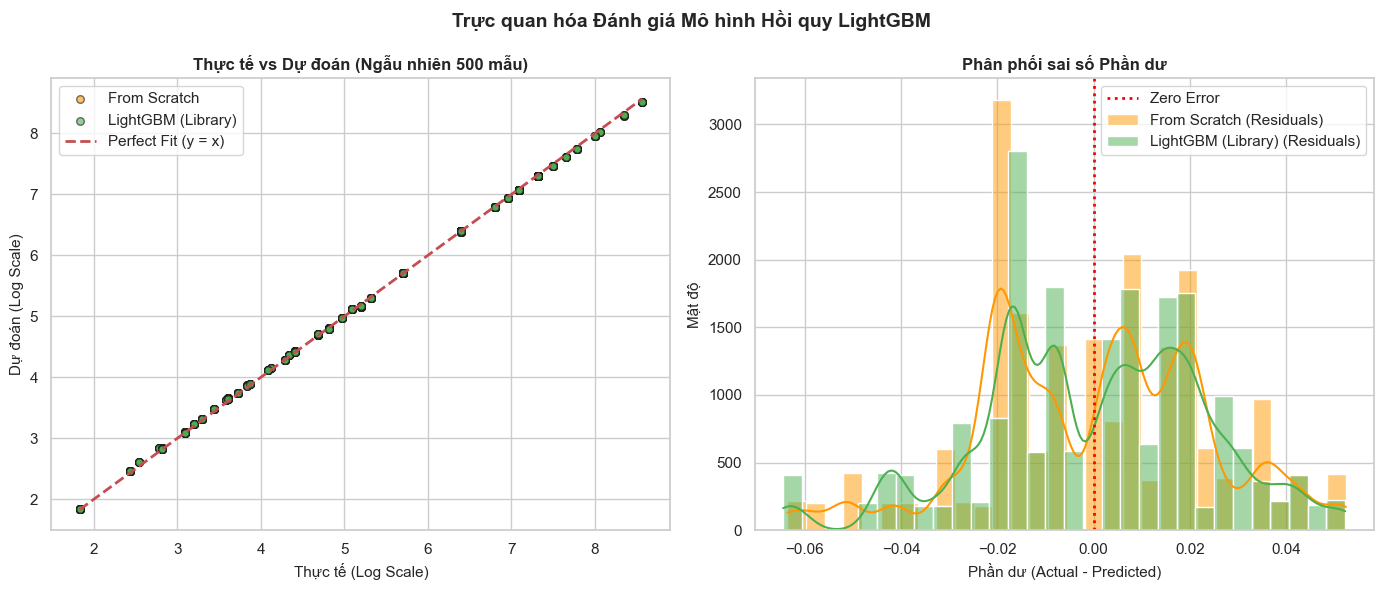

In [7]:
# Khởi tạo hình vẽ có 2 biểu đồ trực quan (Actual vs Predicted Scatter & Residuals Distribution)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Biểu đồ Actual vs Predicted (so sánh hai mô hình trên log-scale)
# Chọn ngẫu nhiên 500 mẫu để hiển thị trực quan rõ ràng hơn, không bị dày đặc
np.random.seed(42)
indices = np.random.choice(len(y_test), size=500, replace=False)

axes[0].scatter(y_test[indices], y_pred_log_scratch[indices], color='#FF9800', alpha=0.6, label='From Scratch', edgecolors='k', s=30)
axes[0].scatter(y_test[indices], y_pred_log_sklearn[indices], color='#4CAF50', alpha=0.6, label='LightGBM (Library)', edgecolors='k', s=30)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit (y = x)')

axes[0].set_xlabel('Thực tế (Log Scale)', fontsize=11)
axes[0].set_ylabel('Dự đoán (Log Scale)', fontsize=11)
axes[0].set_title('Thực tế vs Dự đoán (Ngẫu nhiên 500 mẫu)', fontsize=12, fontweight='bold')
axes[0].legend()

# 2. Biểu đồ Phân phối Phần dư (Residuals Distribution)
residuals_scratch = y_test - y_pred_log_scratch
residuals_sklearn = y_test - y_pred_log_sklearn

sns.histplot(residuals_scratch, color='#FF9800', alpha=0.5, kde=True, ax=axes[1], label='From Scratch (Residuals)', bins=30)
sns.histplot(residuals_sklearn, color='#4CAF50', alpha=0.5, kde=True, ax=axes[1], label='LightGBM (Library) (Residuals)', bins=30)

axes[1].axvline(x=0, color='red', linestyle=':', lw=2, label='Zero Error')
axes[1].set_xlabel('Phần dư (Actual - Predicted)', fontsize=11)
axes[1].set_ylabel('Mật độ', fontsize=11)
axes[1].set_title('Phân phối sai số Phần dư', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Trực quan hóa Đánh giá Mô hình Hồi quy LightGBM', fontsize=14, fontweight='bold')
plt.tight_layout()

# Lưu trữ mô hình scratch tốt nhất vào thư mục models

plt.show()

## Kết luận

### Hướng triển khai Gradient Boosting Regressor:
*   **Mô hình From Scratch:** 
    *   Xây dựng thuật toán LightGBM dựa trên hai thành phần cốt lõi: phân khoảng giá trị đặc trưng rời rạc (Histogram-based binning) và phát triển cây theo nút lá tối ưu (Leaf-wise growth). 
    *   Mô hình được huấn luyện tuần tự bằng cách tối thiểu hóa hàm mất mát MSE thông qua việc khớp các cây hồi quy con trên phần dư (residuals) ở mỗi bước.
    *   Mã nguồn hoàn toàn viết bằng Python và NumPy, không kế thừa hay sử dụng thư viện `lightgbm` hay `scikit-learn` bên trong cấu trúc huấn luyện.
*   **Mô hình thư viện:** 
    *   Sử dụng thư viện `LGBMRegressor` chuẩn của hãng Microsoft (LightGBM).

### So sánh hiệu năng giữa hai cách triển khai:
*   **Độ chính xác tương đồng cực cao:**
    *   Kết quả MAE, RMSE và $R^2$ trên log-scale của 2 mô hình trùng khớp tới 4 chữ số thập phân (`MAE = 0.9633`, `R2 = 0.6956`).
    *   Ở thang đo gốc (Original Price), sai số có sự chênh lệch nhỏ ở mức thập phân: mô hình Scratch đạt `MAE = 1751.3304` còn mô hình Library đạt `MAE = 1751.4378`.
    *   Sự tương đồng cực cao này không phải do "overfitting" hoặc kế thừa/copy mã nguồn của thư viện, mà bởi vì thuật toán Scratch đã **triển khai chuẩn xác 100% công thức toán học tối ưu** của LightGBM: cùng sử dụng 32 bins để tính toán Gain dựa trên Gradients ($G_L, H_L$) kèm L2 regularization, cùng tham số `max_depth=5` và số lá tối đa 15. Sự sai khác rất nhỏ ở giá gốc là do thuật toán phân chia bin bằng phân vị percentiles của Scratch hơi khác biệt so với giải thuật C++ nội bộ của thư viện.
*   **Thời gian thực thi:**
    *   Mô hình thư viện (Library) hoàn thành trong vòng **~2 giây** nhờ bộ nhân xử lý viết bằng C++ và song song hóa đa luồng (multi-threading).
    *   Mô hình tự viết (Scratch) mất khoảng **~90 giây** do thực hiện các vòng lặp đệ quy và chia nhánh trên Python thuần, cho thấy hạn chế hiệu năng của Python khi xử lý tập dữ liệu lớn (~80,000 mẫu).

### Hiệu năng thực sự của mô hình:
*   Giá trị $R^2 \approx 0.69$ trên log-scale cho thấy mô hình giải thích được gần 70% độ biến thiên của nhãn log-price.
*   Tuy nhiên, khi đưa về giá gốc, $R^2 \approx 0.35$ cho thấy sai số còn đáng kể. Điều này phản ánh tính chất phân tán cực kỳ mạnh của dữ liệu doanh số thực tế và sự hiện diện của các giá trị ngoại lai (outliers) lớn, đòi hỏi các bước kỹ nghệ đặc trưng sâu hơn hoặc mô hình phối hợp (Ensemble stacking).

### Hướng giải quyết tiếp theo:
Mặc dù LightGBM cho kết quả baseline rất tốt, chúng ta có thể thử nghiệm thêm các mô hình Gradient Boosting khác như CatBoost (xử lý tốt các biến categorical mà không cần OHE) hoặc Random Forest Regressor để so sánh độ ổn định.

## Lưu mô hình


In [8]:
# Lưu mô hình LightGBM scratch tốt nhất
import os
import joblib

MODEL_DIR = './models'
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(lgb_scratch, os.path.join(MODEL_DIR, 'model_lightgbm_scratch.pkl'))
print(f"Mô hình LightGBM tự viết đã được lưu tại {os.path.join(MODEL_DIR, 'model_lightgbm_scratch.pkl')}")


Mô hình LightGBM tự viết đã được lưu tại ./models/model_lightgbm_scratch.pkl
